[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NelvaAdalit/Nelva-Adalit-AI-Portfolio/blob/main/4-aprendizaje-por-refuerzo/rompecabezas-deslizante/01_aprendizaje_por_refuerzo_rompecabezas.ipynb)

# Aprendizaje por Refuerzo: Rompecabezas Deslizante de 8 Fichas (Sliding 8-Puzzle)
Este cuaderno contiene la implementación de un agente de **Aprendizaje por Refuerzo por Gradiente (Policy Gradient / Tabular Gradient Bandit)** entrenado para resolver el clásico rompecabezas deslizante de 8 fichas en una cuadrícula de 3x3.

El estado objetivo es:
```
1 2 3
4 5 6
7 8 0
```
Donde `0` representa el espacio vacío.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
import torch
import os

## 1. Definición del Entorno (Environment)
El entorno modela el tablero de 3x3. El método `reiniciar` desordena el tablero aplicando `pasos_desorden` movimientos aleatorios válidos partiendo del estado meta, garantizando que el rompecabezas siempre sea resoluble. El método `dar_paso` intercambia la ficha elegida con el espacio vacío.

In [2]:
class EntornoRompecabezas():
    def __init__(self, pasos_desorden=10):
        self.estado_meta = (1, 2, 3, 4, 5, 6, 7, 8, 0)
        self.pasos_desorden = pasos_desorden
        self.vecinos = {
            0: [1, 3],       1: [0, 2, 4],    2: [1, 5],
            3: [0, 4, 6],    4: [1, 3, 5, 7], 5: [2, 4, 8],
            6: [3, 7],       7: [4, 6, 8],    8: [5, 7]
        }
        self.estado = self.estado_meta

    def reiniciar(self):
        self.estado = self.estado_meta
        for _ in range(self.pasos_desorden):
            movimientos_posibles = self.movimientos_validos()
            accion = random.choice(movimientos_posibles)
            self.dar_paso(accion)
        return self.estado

    def movimientos_validos(self):
        indice_vacio = self.estado.index(0)
        return self.vecinos[indice_vacio]
    
    def dar_paso(self, indice_accion):
        indice_vacio = self.estado.index(0)
        nuevo_estado = list(self.estado)
        nuevo_estado[indice_vacio], nuevo_estado[indice_accion] = nuevo_estado[indice_accion], nuevo_estado[indice_vacio]
        self.estado = tuple(nuevo_estado)
        
        if self.estado == self.estado_meta:
            return self.estado, 10, True
        else:
            return self.estado, -1, False

## 2. Definición del Agente de Gradiente (Gradient-based RL Agent)
Este agente utiliza el método de gradiente de política tabular (Tabular Policy Gradient). Mantiene un diccionario de preferencias $H(S, A)$ para cada par estado-acción. Las probabilidades de tomar cada acción se calculan mediante una función Softmax sobre estas preferencias. El aprendizaje se realiza actualizando las preferencias de acuerdo al resultado total del episodio comparado con una recompensa media de referencia (baseline).

In [3]:
class AgenteGradienteRompecabezas():
    def __init__(self, alfa=0.1):
        self.preferencias = {}
        self.alfa = alfa
        self.historial_partida = []
        self.recompensa_media = 0.0
        self.partidas_jugadas = 0

    def obtener_h(self, estado, accion):
        return self.preferencias.get((estado, accion), 0.0)
    
    def mover(self, estado, movimientos_posibles):
        valores_h = np.array([self.obtener_h(estado, a) for a in movimientos_posibles], dtype=float)
        exp_h = np.exp(valores_h - np.max(valores_h))
        probabilidades_pi = exp_h / np.sum(exp_h)

        indice_elegido = np.random.choice(len(movimientos_posibles), p=probabilidades_pi)
        accion_elegida = movimientos_posibles[indice_elegido]
 
        self.historial_partida.append((estado, movimientos_posibles, accion_elegida, probabilidades_pi))
        return accion_elegida
    
    def aprender_de_partida(self, recompensa_total):
        self.partidas_jugadas += 1
        self.recompensa_media += (recompensa_total - self.recompensa_media) / self.partidas_jugadas

        for estado, movs_validos, accion_tomada, probs_pi in self.historial_partida:
            for j, accion in enumerate(movs_validos):
                h_actual = self.obtener_h(estado, accion)
                if accion == accion_tomada:
                    nuevo_h = h_actual + self.alfa * (recompensa_total - self.recompensa_media) * (1 - probs_pi[j])
                else:
                    nuevo_h = h_actual - self.alfa * (recompensa_total - self.recompensa_media) * probs_pi[j]
                self.preferencias[(estado, accion)] = nuevo_h
        self.historial_partida = []

## 3. Bucle de Entrenamiento (Training Loop)
Entrenamos al agente durante 3000 episodios. En cada episodio desordenamos el tablero 10 pasos y permitimos que el agente realice acciones hasta un máximo de 100 movimientos. Al final del entrenamiento, guardamos los pesos aprendidos (las preferencias) en un archivo `.pt` utilizando PyTorch.

In [4]:
# Inicializar entorno y agente
env = EntornoRompecabezas(pasos_desorden=10)
agente = AgenteGradienteRompecabezas(alfa=0.15)

num_episodios = 3000
max_pasos_por_episodio = 100
historial_recompensas = []
exitos_recientes = 0
tasa_exito = []

print("Entrenando al agente...")
for episodio in tqdm(range(num_episodios)):
    estado = env.reiniciar()
    recompensa_total = 0
    resuelto = False
    
    for paso in range(max_pasos_por_episodio):
        movs = env.movimientos_validos()
        accion = agente.mover(estado, movs)
        nuevo_estado, recompensa, resuelto = env.dar_paso(accion)
        recompensa_total += recompensa
        estado = nuevo_estado
        
        if resuelto:
            break
            
    agente.aprender_de_partida(recompensa_total)
    historial_recompensas.append(recompensa_total)
    
    if resuelto:
        exitos_recientes += 1
        
    if (episodio + 1) % 100 == 0:
        tasa_exito.append((episodio + 1, exitos_recientes / 100.0))
        exitos_recientes = 0

# Guardar pesos en archivo .pt
path_pesos = "pesos_rompecabezas.pt"
torch.save(agente.preferencias, path_pesos)
print(f"\nEntrenamiento completado. Pesos guardados en: {os.path.abspath(path_pesos)}")

Entrenando al agente...


  0%|          | 0/3000 [00:00<?, ?it/s]

  3%|▎         | 76/3000 [00:00<00:03, 759.90it/s]

  6%|▌         | 170/3000 [00:00<00:03, 865.59it/s]

  9%|▊         | 257/3000 [00:00<00:03, 850.93it/s]

...

 94%|█████████▎| 2809/3000 [00:03<00:00, 940.32it/s]

 97%|█████████▋| 2905/3000 [00:03<00:00, 906.96it/s]

100%|█████████▉| 2999/3000 [00:03<00:00, 916.00it/s]

100%|██████████| 3000/3000 [00:03<00:00, 918.19it/s]


Entrenamiento completado. Pesos guardados en: D:\Nelva-Adalit-AI-Portfolio\4-aprendizaje-por-refuerzo\rompecabezas-deslizante\pesos_rompecabezas.pt


## 4. Visualización del Rendimiento (Plots)
Graficamos la evolución de la recompensa acumulada promedio (suavizada con media móvil) y la tasa de éxito de resolución del tablero cada 100 episodios.

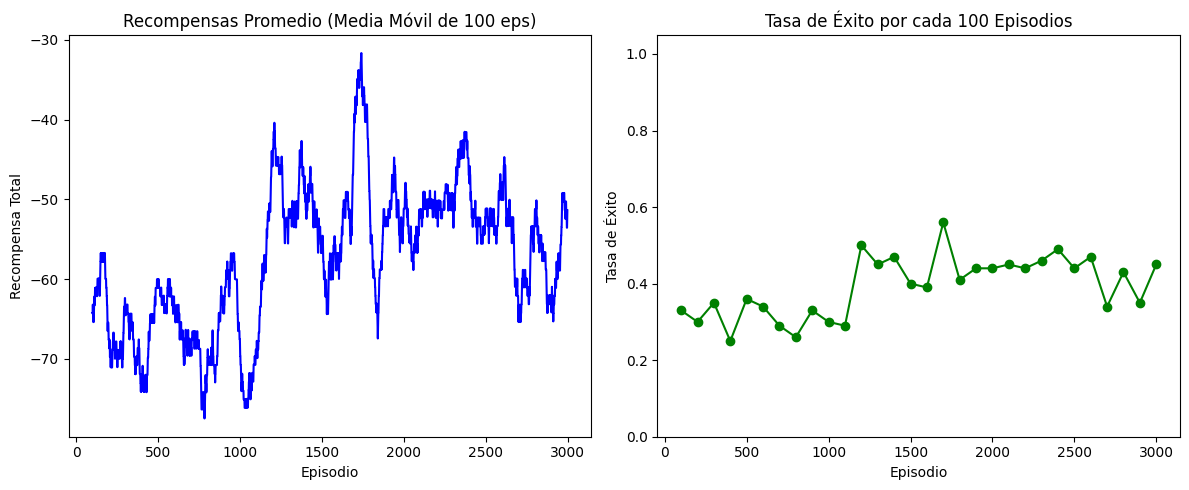

In [5]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df_rew = pd.DataFrame(historial_recompensas)
plt.plot(df_rew.rolling(100).mean(), color='blue')
plt.title("Recompensas Promedio (Media Móvil de 100 eps)")
plt.xlabel("Episodio")
plt.ylabel("Recompensa Total")

plt.subplot(1, 2, 2)
eps, tasas = zip(*tasa_exito)
plt.plot(eps, tasas, marker='o', color='green')
plt.title("Tasa de Éxito por cada 100 Episodios")
plt.xlabel("Episodio")
plt.ylabel("Tasa de Éxito")
plt.ylim(0, 1.05)

plt.tight_layout()
plt.show()

## 5. Prueba de Resolución Paso a Paso (Test)
Ponemos a prueba al agente entrenado. Desordenamos el tablero y permitimos que el agente lo resuelva explotando su política (seleccionando siempre la acción con mayor preferencia).

In [6]:
estado_inicial = env.reiniciar()
print("Tablero Inicial Desordenado:")
print(np.array(estado_inicial).reshape(3, 3))

estado = estado_inicial
max_pasos = 20
camino = [estado]
resuelto = False

for paso in range(max_pasos):
    if estado == env.estado_meta:
        resuelto = True
        break
    movs = env.movimientos_validos()
    # Explotación pura
    valores_h = [agente.obtener_h(estado, a) for a in movs]
    accion = movs[np.argmax(valores_h)]
    estado, _, _ = env.dar_paso(accion)
    camino.append(estado)

if resuelto:
    print(f"\n¡Resuelto exitosamente en {len(camino)-1} pasos!")
    for idx, est in enumerate(camino):
        print(f"Paso {idx}:")
        print(np.array(est).reshape(3, 3))
else:
    print("\nNo se pudo resolver en el número máximo de pasos de prueba.")

Tablero Inicial Desordenado:
[[1 2 0]
 [5 6 3]
 [4 7 8]]

No se pudo resolver en el número máximo de pasos de prueba.
